In [23]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from scipy import stats

In [2]:
import sys
sys.version

'3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]'

# Bulgaria Before and After 1989: Demographic and Health Trends

## Working research question
Are the trends in selected demographic and health indicators statistically different between the communist period and the post-communist period in Bulgaria?

## Introduction

This project explores whether selected demographic and health indicators in Bulgaria differ between the communist and post-communist periods.

The analysis focuses on a small set of long-run indicators that are available in a usable form across a broad time range. The goal is not to make a political judgement about the two periods, but to examine whether measurable demographic and health trends show clear differences before and after 1989.

## Research question and objectives

### Main research question
Are the trends in selected demographic and health indicators statistically different between the communist period and the post-communist period in Bulgaria?

### Objectives
- to prepare a clean working dataset for selected demographic and health indicators
- to compare the two periods using matched time windows where possible
- to examine whether the selected indicators show visible trend differences across the two periods
- to use more than one data source in a meaningful way
- indentifying and discussing important limitations in source coverage and comparability

## Data sources

### Main source
- World Bank: main long-run source for the selected indicators

### Supporting sources
- National Statistical Institute (NSI), Bulgaria: used for population overlap and source comparison in the later period
- Eurostat: for fertility rate comparisson and infant mortality

## Scope and selected indicators

The project currently focuses on the following indicators:
- population, total
- fertility rate
- infant mortality

These indicators were chosen because they are central to demographic and health change and are available in usable long-run series.

## Period definition

The comparison is intended to use matched time windows for the two periods where possible.

A likely working approach is:
- communist period: 1960-1988
- post-communist period: 1990-2018

The year 1989 may be treated as a transition year and excluded from the formal comparison.

## Data preparation overview

The data preparation work is carried out in a separate notebook focused on inspection and cleaning.

That work includes:
- selecting the relevant World Bank indicators
- reshaping the World Bank data into a year-based format
- extracting, cleaning and merging NSI population data
- comparing overlapping population values between World Bank and NSI
- examination of Eurostat data

In [3]:
# define project-relative paths for the raw and processed datasets

current_dir = Path.cwd()

if current_dir.name == "bulgaria_before_after_1989":
    project_root = current_dir
elif (current_dir / "bulgaria_before_after_1989").exists():
    project_root = current_dir / "bulgaria_before_after_1989"
else:
    raise FileNotFoundError("Project root folder 'bulgaria_before_after_1989' was not found from the current working directory.")

raw_data_dir = project_root / "data" / "raw"
processed_data_dir = project_root / "data" / "processed"

In [4]:
wb_population_clean_path = processed_data_dir / "wb_population_clean.csv"
nsi_population_combined_path = processed_data_dir / "nsi_population_combined.csv"

## Population overlap comparison between World Bank and NSI

Population is currently the strongest indicator in terms of visible two-source comparison in this project.  
To make the second source meaningful in the workflow, the cleaned NSI population data was compared with the World Bank population series for the overlapping years.

The aim of this comparison is not to decide which source is “correct”, but to examine whether the two series are close enough to support each other and to identify whether any systematic differences are present.

### Comparison approach

The World Bank population series was merged with the cleaned NSI population table using the common `year` column and keeping only overlapping years.

Two types of difference were then calculated:
- absolute difference
- relative difference in percent

The relative difference was calculated using the NSI value as the denominator, so the percentage shows how far the World Bank value is from the NSI value relative to the NSI series. NSI is used here as the national reference baseline for the overlapping years.

In [5]:
wb_population_clean_path = processed_data_dir / "wb_population_clean.csv"
nsi_population_combined_path = processed_data_dir / "nsi_population_combined.csv"

wb_population = pd.read_csv(wb_population_clean_path)
nsi_population_combined = pd.read_csv(nsi_population_combined_path)

wb_population.head(), nsi_population_combined.head()

(   year  population_total_wb
 0  1960            7867374.0
 1  1961            7943118.0
 2  1962            8012946.0
 3  1963            8078145.0
 4  1964            8144340.0,
    year  population_total_nsi
 0  2001               7868815
 1  2002               7805506
 2  2003               7745147
 3  2004               7688573
 4  2005               7629371)

In [6]:
# merge the World Bank and NSI population tables and calculate source differences

population_comparison = pd.merge(
    wb_population,
    nsi_population_combined,
    on="year",
    how="inner"
)

population_comparison["absolute_difference"] = (
    population_comparison["population_total_wb"] - population_comparison["population_total_nsi"]
)

population_comparison["relative_difference_pct"] = (
    population_comparison["absolute_difference"] / population_comparison["population_total_nsi"]
) * 100

population_comparison.head()

,year,population_total_wb,population_total_nsi,absolute_difference,relative_difference_pct
0,2001,8009142.0,7868815,140327.0,1.783331
1,2002,7837161.0,7805506,31655.0,0.405547
2,2003,7775327.0,7745147,30180.0,0.389663
3,2004,7716860.0,7688573,28287.0,0.367910
4,2005,7658972.0,7629371,29601.0,0.387987


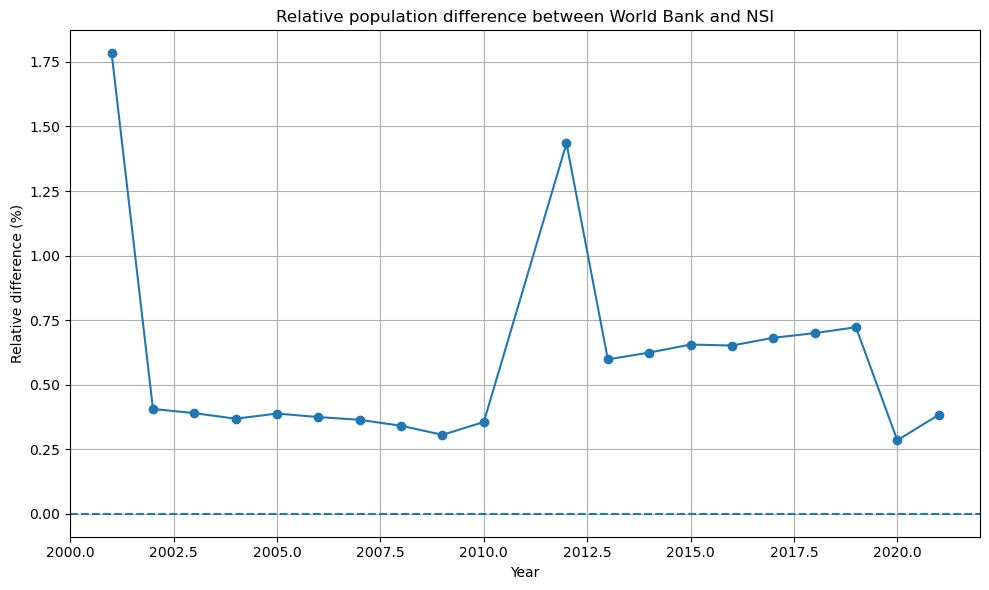

In [7]:
# visualize the relative population difference between the World Bank and NSI series over time

plt.figure(figsize=(10, 6))

plt.plot(
    population_comparison["year"],
    population_comparison["relative_difference_pct"],
    marker="o"
)

plt.axhline(y=0, linestyle="--")
plt.title("Relative population difference between World Bank and NSI")
plt.xlabel("Year")
plt.ylabel("Relative difference (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation

The calculated differences suggest that the two series are broadly consistent, while still showing small non-zero discrepancies.

Observed differences are likely related to revisions, update timing, or harmonization practices rather than to a completely different demographic picture.

## Infant mortality overlap comparison between World Bank and Eurostat

Infant mortality is compared between the World Bank and Eurostat series for the overlapping years in order to check whether the two sources are consistent enough to support the use of the World Bank series as the main long-run analytical source.

In [8]:
# load the cleaned World Bank and Eurostat infant mortality tables prepared in the first notebook

wb_infant_mortality_clean_path = processed_data_dir / "wb_infant_mortality_clean.csv"
infant_mortality_eurostat_clean_path = processed_data_dir / "infant_mortality_eurostat_clean.csv"

wb_infant_mortality = pd.read_csv(wb_infant_mortality_clean_path)
infant_mortality_eurostat_clean = pd.read_csv(infant_mortality_eurostat_clean_path)

wb_infant_mortality.head(), infant_mortality_eurostat_clean.head()

(   year  infant_mortality_wb
 0  1960                 44.9
 1  1961                 40.4
 2  1962                 36.8
 3  1963                 34.2
 4  1964                 32.4,
    year  infant_mortality_eurostat
 0  2010                        9.4
 1  2011                        8.5
 2  2012                        7.8
 3  2013                        7.3
 4  2014                        7.6)

### Comparison approach

The cleaned World Bank infant mortality series and the cleaned Eurostat infant mortality series are merged using the common `year` column and keeping only overlapping years.

As in the population comparison, both absolute and relative differences are calculated in order to assess the closeness of the two sources over the shared period.

In [9]:
# compare the World Bank and Eurostat infant mortality series over overlapping years

infant_mortality_comparison = pd.merge(
    wb_infant_mortality,
    infant_mortality_eurostat_clean,
    on="year",
    how="inner"
)

infant_mortality_comparison["absolute_difference"] = (
    infant_mortality_comparison["infant_mortality_wb"]
    - infant_mortality_comparison["infant_mortality_eurostat"]
)

infant_mortality_comparison["relative_difference_pct"] = (
    infant_mortality_comparison["absolute_difference"]
    / infant_mortality_comparison["infant_mortality_eurostat"]
) * 100

infant_mortality_comparison[["absolute_difference", "relative_difference_pct"]].describe()


,absolute_difference,relative_difference_pct
count,10.0000,10.000000
mean,0.0300,0.349228
std,0.3093,4.147283
min,-0.3000,-4.687500
25%,-0.2500,-2.840046
50%,-0.0500,-0.769231
75%,0.2000,2.860963
max,0.5000,6.849315


### Interpretation

The overlap comparison shows that the World Bank and Eurostat infant mortality series are very close, but not identical.

The differences are small in both absolute and relative terms. 

## Fertility overlap comparison between World Bank and Eurostat

The total fertility rate from Eurostat is compared with the World Bank fertility series over the overlapping years in order to evaluate source consistency for this indicator.

In [10]:
# load the cleaned World Bank and Eurostat fertility tables prepared in the first notebook

wb_fertility_clean_path = processed_data_dir / "wb_fertility_clean.csv"
fertility_eurostat_clean_path = processed_data_dir / "fertility_eurostat_clean.csv"

wb_fertility = pd.read_csv(wb_fertility_clean_path)
fertility_eurostat_clean = pd.read_csv(fertility_eurostat_clean_path)

wb_fertility.head(), fertility_eurostat_clean.head()

(   year  fertility_rate_wb
 0  1960               2.31
 1  1961               2.29
 2  1962               2.24
 3  1963               2.21
 4  1964               2.19,
    year  fertility_rate_eurostat
 0  2005                     1.37
 1  2006                     1.44
 2  2007                     1.49
 3  2008                     1.56
 4  2009                     1.66)

### Comparison approach

The cleaned World Bank fertility series and the cleaned Eurostat total fertility rate series are merged using the common `year` column and keeping only overlapping years.

Absolute and relative differences are calculated in the same way as in the previous overlap comparisons.

In [11]:
# compare the World Bank and Eurostat fertility series over overlapping years

fertility_comparison = pd.merge(
    wb_fertility,
    fertility_eurostat_clean,
    on="year",
    how="inner"
)

fertility_comparison["absolute_difference"] = (
    fertility_comparison["fertility_rate_wb"]
    - fertility_comparison["fertility_rate_eurostat"]
)

fertility_comparison["relative_difference_pct"] = (
    fertility_comparison["absolute_difference"]
    / fertility_comparison["fertility_rate_eurostat"]
) * 100

fertility_comparison[["absolute_difference", "relative_difference_pct"]].describe()

,absolute_difference,relative_difference_pct
count,15.0,15.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


### Interpretation

The overlap comparison shows that the World Bank and Eurostat fertility series match exactly for the overlapping years included in the Eurostat file.

In this case, the absolute and relative differences are zero across the observed overlap period. This strongly supports the use of the World Bank fertility series as the main long-run analytical source, while Eurostat serves as an official supporting source confirming the consistency of the values in the overlapping years.

## Role of the sources in the final analysis

The overlap comparisons show that the World Bank series are consistent with the supporting official sources used in this project. For that reason, the World Bank data is used as the main long-run analytical source for the formal descriptive analysis, matched-period comparison, and hypothesis testing.

NSI and Eurostat are used to strengthen confidence in the source quality through overlap validation where sufficient coverage is available.

## Analytical approach and methodological justification

The analytical part of the project combines descriptive statistics, visual trend analysis, matched-period comparison, and hypothesis testing.

This approach is suitable because the selected indicators are long-run annual time series and the main goal is comparative rather than predictive. Descriptive statistics and visual inspection are used to understand the overall behavior, range, and variability of the indicators before moving to formal comparison and testing [1].

Matched-period comparison is appropriate because the project is focused on differences between two historical periods rather than on building a predictive model. This allows the analysis to concentrate directly on whether the selected indicators behave differently before and after 1989.

Hypothesis testing is then used to evaluate whether the observed differences between the two periods are statistically meaningful rather than random variation. In standard statistical practice, hypothesis tests are used to assess claims about population parameters, while interval estimation is used to quantify uncertainty around estimates [1].

The World Bank series is used as the main analytical dataset because the World Development Indicators provide broad long-run coverage for the selected variables. In this project, the main indicators used from that source are Population, total (SP.POP.TOTL), Fertility rate, total (births per woman) (SP.DYN.TFRT.IN), and Mortality rate, infant (per 1,000 live births) (SP.DYN.IMRT.IN) [2][3][4][5].

Supporting official sources are used for overlap validation where sufficient coverage is available. The National Statistical Institute is Bulgaria’s official statistical authority, while Eurostat provides the official datasets used here for fertility indicators (`demo_find`) and infant mortality rates (`demo_minfind`) [6][7][8].

## Descriptive analysis of the long-run World Bank series
This section begins the main analytical use of the long-run World Bank dataset. After the overlap comparisons with supporting sources, the World Bank series is used as the main basis for descriptive analysis and later period comparison.

In [12]:
# load the cleaned main World Bank table prepared in the first notebook

wb_main_clean_path = processed_data_dir / "wb_main_clean.csv"
wb_main = pd.read_csv(wb_main_clean_path)

wb_main.head()

,year,population_total,life_expectancy,fertility_rate,infant_mortality
0,1960,7867374.0,69.247561,2.31,44.9
1,1961,7943118.0,70.195610,2.29,40.4
2,1962,8012946.0,69.491951,2.24,36.8
3,1963,8078145.0,70.309268,2.21,34.2
4,1964,8144340.0,71.121220,2.19,32.4


In [13]:
# inspect the structure of the cleaned main World Bank table
wb_main.shape, wb_main.columns, wb_main.dtypes

((66, 5),
 Index(['year', 'population_total', 'life_expectancy', 'fertility_rate',
        'infant_mortality'],
       dtype='str'),
 year                  int64
 population_total    float64
 life_expectancy     float64
 fertility_rate      float64
 infant_mortality    float64
 dtype: object)

In [14]:
# summarize the main descriptive statistics of the selected World Bank indicators

wb_main[["population_total", "fertility_rate", "infant_mortality"]].describe()

,population_total,fertility_rate,infant_mortality
count,6.500000e+01,65.000000,65.000000
mean,8.031946e+06,1.788769,17.116923
std,7.805709e+05,0.356719,9.540351
min,6.441421e+06,1.090000,4.600000
25%,7.492561e+06,1.510000,9.500000
50%,8.256786e+06,1.800000,15.300000
75%,8.678745e+06,2.090000,23.500000
max,8.981446e+06,2.310000,44.900000


### Long-run trend: fertility rate

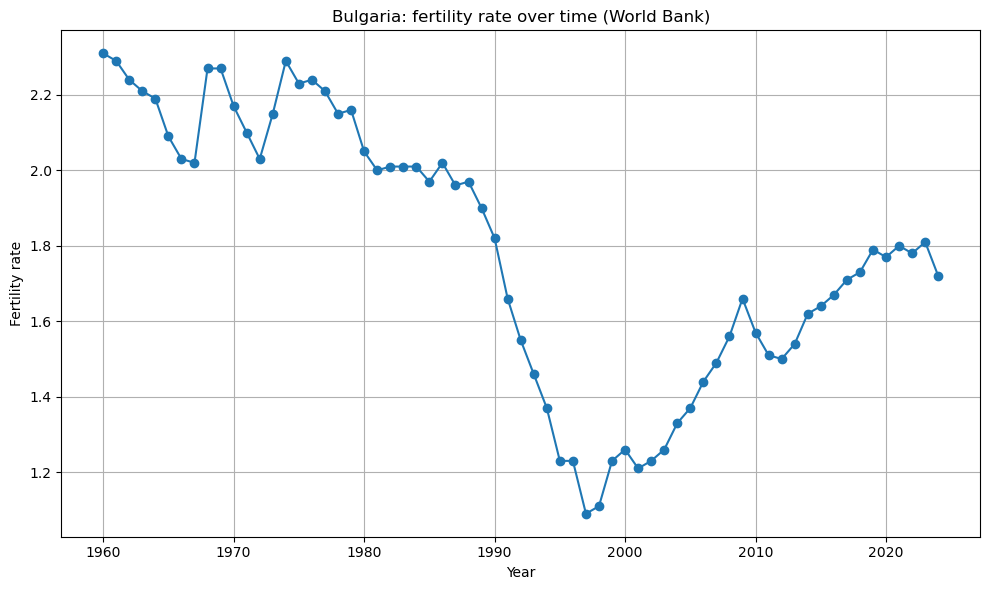

In [15]:
# visualize the long-run World Bank fertility rate series

plt.figure(figsize=(10, 6))

plt.plot(
    wb_main["year"],
    wb_main["fertility_rate"],
    marker="o"
)

plt.title("Bulgaria: fertility rate over time (World Bank)")
plt.xlabel("Year")
plt.ylabel("Fertility rate")
plt.grid(True)
plt.tight_layout()
plt.show()


### Interpretation

The long-run fertility series shows the broad demographic trend across the full observation period. A noticeable decline becomes visible toward the end of the first selected time period. Although the fertility rate increases later, it does not reach the earlier peak observed in the series. This first visual inspection is useful before moving to the formal comparison between the communist and post-communist periods.

### Fertility rate: descriptive comparison between the two periods

In [16]:
# define the two historical periods used for the formal comparison
communist_period = wb_main[(wb_main["year"] >= 1960) & (wb_main["year"] <= 1988)].copy()
post_communist_period = wb_main[(wb_main["year"] >= 1990) & (wb_main["year"] <= 2018)].copy()

communist_period.shape, post_communist_period.shape

((29, 5), (29, 5))

In [17]:
# compare the fertility rate descriptively between the communist and post-communist periods

fertility_period_comparison = pd.DataFrame({
    "communist_period": communist_period["fertility_rate"].describe(),
    "post_communist_period": post_communist_period["fertility_rate"].describe()
})

fertility_period_comparison

,communist_period,post_communist_period
count,29.000000,29.00000
mean,2.125862,1.45000
std,0.114876,0.20114
min,1.960000,1.09000
25%,2.020000,1.26000
50%,2.150000,1.49000
75%,2.230000,1.62000
max,2.310000,1.82000


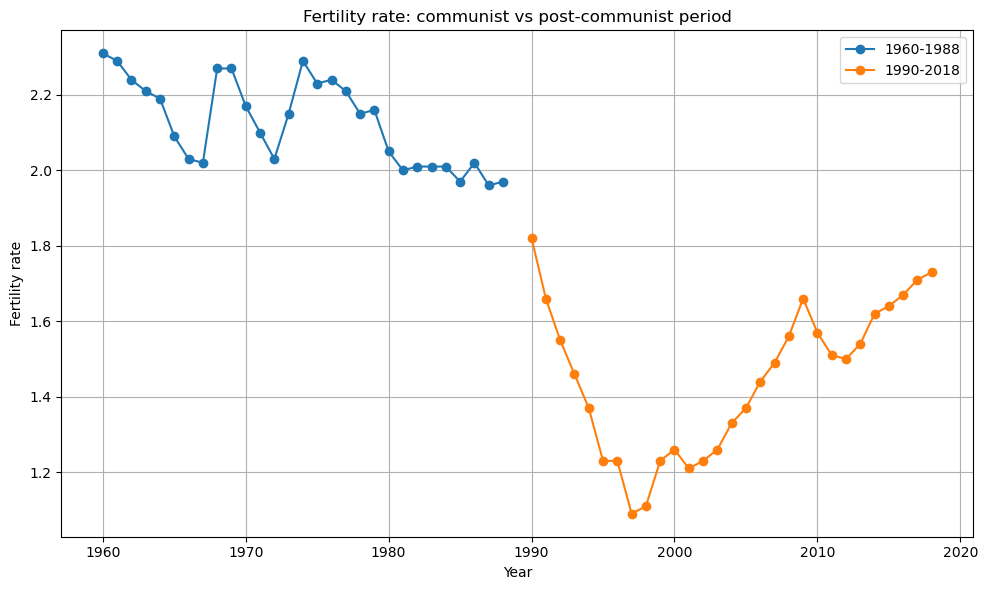

In [18]:
# visualize the fertility rate in the two historical periods

plt.figure(figsize=(10, 6))

plt.plot(
    communist_period["year"],
    communist_period["fertility_rate"],
    marker="o",
    label="1960-1988"
)

plt.plot(
    post_communist_period["year"],
    post_communist_period["fertility_rate"],
    marker="o",
    label="1990-2018"
)

plt.title("Fertility rate: communist vs post-communist period")
plt.xlabel("Year")
plt.ylabel("Fertility rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation

The descriptive comparison suggests that fertility is higher in the communist-period window and lower in the post-communist-period window. The later period does not return to the earlier peak values observed in the series.

This is still a descriptive result, but it provides an initial indication of a meaningful difference between the two periods.

### Infant mortality: descriptive comparison between the two periods

In [19]:
# compare infant mortality descriptively between the communist and post-communist periods

infant_mortality_period_comparison = pd.DataFrame({
    "communist_period": communist_period["infant_mortality"].describe(),
    "post_communist_period": post_communist_period["infant_mortality"].describe()
})

infant_mortality_period_comparison

,communist_period,post_communist_period
count,29.000000,29.000000
mean,25.286207,11.537931
std,7.950549,3.471868
min,14.100000,5.800000
25%,18.800000,8.700000
50%,24.700000,11.800000
75%,30.900000,15.000000
max,44.900000,15.600000


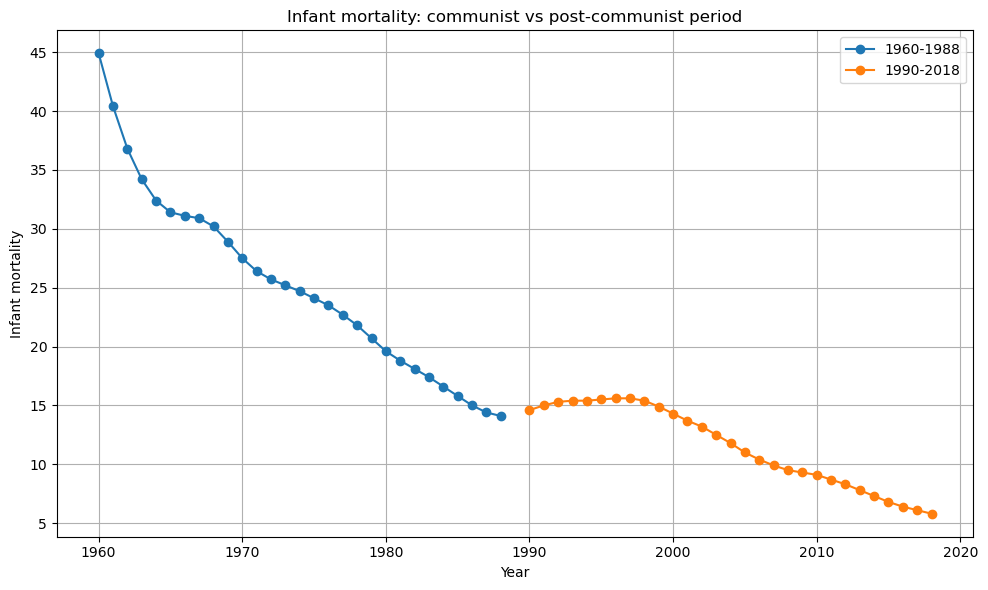

In [20]:
# visualize infant mortality in the two historical periods

plt.figure(figsize=(10, 6))

plt.plot(
    communist_period["year"],
    communist_period["infant_mortality"],
    marker="o",
    label="1960-1988"
)

plt.plot(
    post_communist_period["year"],
    post_communist_period["infant_mortality"],
    marker="o",
    label="1990-2018"
)

plt.title("Infant mortality: communist vs post-communist period")
plt.xlabel("Year")
plt.ylabel("Infant mortality")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation

The descriptive comparison indicates that infant mortality is markedly higher in the communist-period window and clearly lower in the post-communist-period window. The later period shows a sustained downward pattern that visually separates it from the earlier historical period.

### Population: descriptive comparison between the two periods

In [21]:
# compare population descriptively between the communist and post-communist periods

population_period_comparison = pd.DataFrame({
    "communist_period": communist_period["population_total"].describe(),
    "post_communist_period": post_communist_period["population_total"].describe()
})

population_period_comparison

,communist_period,post_communist_period
count,2.900000e+01,2.900000e+01
mean,8.582399e+06,7.768349e+06
std,3.517740e+05,5.974381e+05
min,7.867374e+06,6.710798e+06
25%,8.310226e+06,7.348328e+06
50%,8.678745e+06,7.716860e+06
75%,8.891117e+06,8.312068e+06
max,8.981446e+06,8.718289e+06


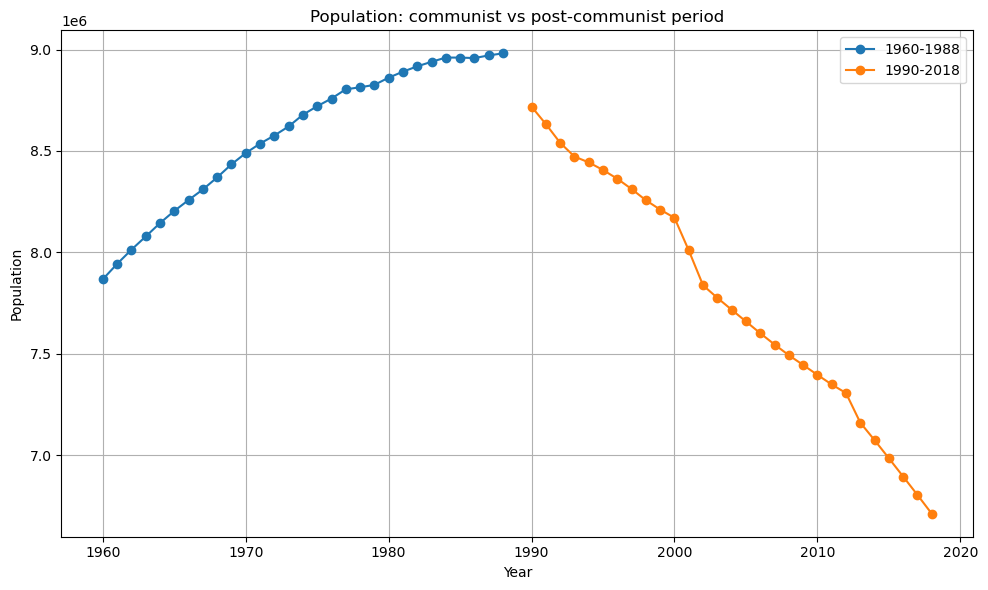

In [22]:
# visualize population in the two historical periods

plt.figure(figsize=(10, 6))

plt.plot(
    communist_period["year"],
    communist_period["population_total"],
    marker="o",
    label="1960-1988"
)

plt.plot(
    post_communist_period["year"],
    post_communist_period["population_total"],
    marker="o",
    label="1990-2018"
)

plt.title("Population: communist vs post-communist period")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation

The descriptive comparison indicates that population levels are generally higher in the communist-period window and lower in the post-communist-period window. The later period shows a visibly lower level and a continued downward tendency relative to the earlier historical period.

## Hypothesis testing

This section uses hypothesis testing to examine whether the differences between the communist and post-communist periods are statistically meaningful for the selected indicators.

For each indicator, the null hypothesis states that the mean value is the same in the two historical periods, while the alternative hypothesis states that the mean value is different between the two periods.

### Fertility rate: hypothesis test

- **H0:** The mean fertility rate is the same in the communist and post-communist periods.
- **H1:** The mean fertility rate is different in the communist and post-communist periods.

In [25]:
# two-sample t-test for population in the two historical periods

population_ttest = stats.ttest_ind(
    communist_period["population_total"],
    post_communist_period["population_total"]
)

population_ttest_result = pd.DataFrame({
    "test_statistic": [population_ttest.statistic],
    "p_value": [population_ttest.pvalue]
})

population_ttest_result

,test_statistic,p_value
0,6.323005,4.511183e-08


### Interpretation

The t-test result suggests that the mean fertility rate differs significantly between the communist and post-communist periods. The p-value is far below the conventional 0.05 significance threshold, so the null hypothesis is rejected.

A statistical support for the descriptive finding that fertility behavior differs between the two selected historical windows is confirmed.

#### Note on interpretation

The t-tests in this project are used as a simple formal comparison between the two historical windows. The yearly observations are treated as two groups for analytical purposes, although time-series data should still be interpreted with caution because they may not fully satisfy all ideal assumptions of independent samples.

### Infant mortality: hypothesis test

- **H0:** The mean infant mortality rate is the same in the communist and post-communist periods.
- **H1:** The mean infant mortality rate is different in the communist and post-communist periods.

In [26]:
# two-sample t-test for infant mortality in the two historical periods

infant_mortality_ttest = stats.ttest_ind(
    communist_period["infant_mortality"],
    post_communist_period["infant_mortality"]
)

infant_mortality_ttest_result = pd.DataFrame({
    "test_statistic": [infant_mortality_ttest.statistic],
    "p_value": [infant_mortality_ttest.pvalue]
})

infant_mortality_ttest_result


,test_statistic,p_value
0,8.533956,1.030663e-11


### Interpretation

The t-test result suggests that the mean infant mortality rate differs significantly between the communist and post-communist periods. The p-value is far below the conventional 0.05 significance threshold, so the null hypothesis for this factor is also rejected.

Confirming descriptive finding that infant mortality differs substantially between the two selected historical windows.

### Population: hypothesis test

- **H0:** The mean population value is the same in the communist and post-communist periods.
- **H1:** The mean population value is different in the communist and post-communist periods.

In [27]:
# two-sample t-test for population in the two historical periods

population_ttest = stats.ttest_ind(
    communist_period["population_total"],
    post_communist_period["population_total"]
)

population_ttest_result = pd.DataFrame({
    "test_statistic": [population_ttest.statistic],
    "p_value": [population_ttest.pvalue]
})

population_ttest_result


,test_statistic,p_value
0,6.323005,4.511183e-08


### Interpretation

The t-test result suggests that the mean population value differs significantly between the communist and post-communist periods. The p-value is far below the conventional 0.05 significance threshold, so the null hypothesis is rejected.

### Summary of hypothesis-testing results

Across all three selected indicators, the t-test results suggest statistically significant differences between the communist and post-communist periods. In each case, the p-value is far below the conventional 0.05 threshold, which leads to rejection of the null hypothesis of equal means.

## Exploratory analysis plan

The exploratory stage of the analysis will focus on:
- long-term trend plots for the selected indicators
- comparisons between the two historical periods
- overlap comparison between different sources where available
- summary statistics for the selected time windows

## Statistical analysis plan

The statistical part of the project is expected to include:
- descriptive statistics
- comparison of matched periods
- confidence intervals
- hypothesis testing for selected indicators

The exact tests will depend on the final structure and coverage of the cleaned datasets.

## Limitations

Some limitations are already visible:
- not all indicators are equally strong across all sources
- NSI coverage is more limited historically for some variables
- different sources may reflect slightly different revision practices or harmonization methods
- overlap comparisons may show small but non-zero differences between sources
- The initial project idea included life expectancy as an additional indicator. During the development of the project, the final analytical scope was narrowed to population, fertility rate, and infant mortality in order to keep the comparison more focused and methodologically consistent under the available source and time constraints.

## Conclusion

This section will summarize the main findings after the final comparative and statistical analysis is completed.

## References

## References

## References

[1] NIST/SEMATECH e-Handbook of Statistical Methods. Exploratory Data Analysis and hypothesis testing reference. Available at: https://www.itl.nist.gov/div898/handbook/eda/section3/eda35.htm

[2] World Bank DataBank. World Development Indicators. Main long-run source used in the project. Available at: https://databank.worldbank.org/source/world-development-indicators

[3] World Bank Metadata Glossary. Population, total (SP.POP.TOTL). Available at: https://databank.worldbank.org/metadataglossary/world-development-indicators/series/SP.POP.TOTL

[4] World Bank Metadata Glossary. Fertility rate, total (births per woman) (SP.DYN.TFRT.IN). Available at: https://databank.worldbank.org/metadataglossary/jobs/series/SP.DYN.TFRT.IN

[5] World Bank Metadata Glossary. Mortality rate, infant (per 1,000 live births) (SP.DYN.IMRT.IN). Available at: https://databank.worldbank.org/metadataglossary/world-development-indicators/series/SP.DYN.IMRT.IN

[6] National Statistical Institute of Bulgaria. Official statistical source used for population overlap comparison. Available at: https://www.nsi.bg/en

[7] Eurostat. Fertility indicators (`demo_find`). Official supporting source used for fertility-rate overlap validation. Available at: https://ec.europa.eu/eurostat/databrowser/view/demo_find/default/table?lang=en

[8] Eurostat. Infant mortality rates (`demo_minfind`). Official supporting source used for infant-mortality overlap validation. Available at: https://ec.europa.eu/eurostat/databrowser/view/demo_minfind/default/table?lang=en